In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv")

In [3]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   str    
 1   industry                  4760 non-null   str    
 2   employment_status         4806 non-null   str    
 3   location                  4792 non-null   str    
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [5]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [6]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

In [7]:
df[categorical] = df[categorical].fillna("NA")
df[numerical] = df[numerical].fillna(0)

In [8]:
df

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
...,...,...,...,...,...,...,...,...,...
4995,organic_search,education,employed,asia,45834.0,2,2,0.37,1
4996,NA,technology,employed,north_america,84831.0,2,5,0.51,0
4997,organic_search,finance,employed,asia,53636.0,4,6,0.75,1
4998,referral,technology,employed,africa,69430.0,4,8,0.79,1


In [9]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [10]:
scores = []
for feature in numerical:
    scores.append((max(roc_auc_score(df_train['converted'], df_train[feature]), roc_auc_score(df_train['converted'], -df_train[feature])), feature))
scores.sort()

In [11]:
scores

[(0.6081977776250831, 'annual_income'),
 (0.7229894623989618, 'number_of_courses_viewed'),
 (0.7649203047563227, 'interaction_count'),
 (0.7882254810906102, 'lead_score')]

In [12]:
y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

In [13]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [14]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [15]:
dv, model = train(df_train, y_train)

y_pred = predict(df_val, dv, model)
print(round(roc_auc_score(y_val, y_pred),3))

0.732


In [16]:
pre = []
rec = []
for t in list(np.linspace(0, 1, 101)):
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    pre.append(tp / (fp + tp) if fp + tp > 0 else 1)
    rec.append(tp / (fn + tp))

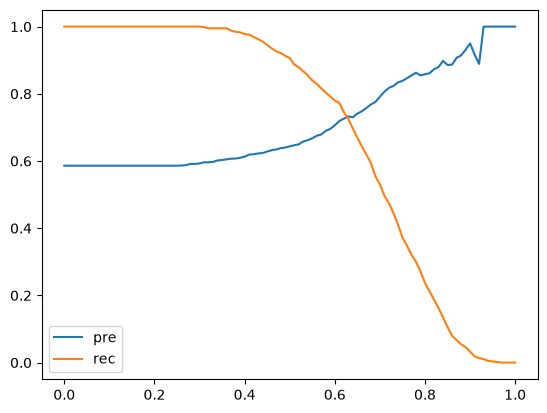

In [17]:
plt.plot(np.linspace(0, 1, 101), pre, label='pre')
plt.plot(np.linspace(0, 1, 101), rec, label='rec')
plt.legend()
plt.show()

In [18]:
idx = np.argmin(np.abs(np.array(rec) - np.array(pre)))
print(idx)
print(rec[idx])
print(pre[idx])

63
0.7252559726962458
0.7327586206896551


In [19]:
def f1(x, y):
    return 2 * x * y / (x + y)

In [20]:
print(np.argmin(f1(np.array(rec), np.array(pre))))

97


In [21]:
idx = 0
f=0
thr=0
for t in list(np.linspace(0, 1, 101)):
    if rec[idx] != 0 and pre[idx] != 0:
        f_new=f1(rec[idx], pre[idx])
        if f_new>f:
            f=f_new
            thr=t
    idx+=1
print(thr)
print(f)

0.41000000000000003
0.7576158940397352


In [24]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []
for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    y_train = df_train.converted.values
    y_val = df_val.converted.values
    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
print(np.std(scores))

0.006853233151022138


In [28]:
n_splits = 5

for C in [0.000001, 0.001, 1]:
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1e-06 0.617 +- 0.019
C=0.001 0.749 +- 0.010
C=1 0.732 +- 0.007
